In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_curve, auc, confusion_matrix,
                             classification_report, ConfusionMatrixDisplay)

In [2]:
# Load your dataset
df = pd.read_csv('health_dataset_50_records.csv')

# Check it
print(df.shape)
print(df.head())
print(df.describe())

(50, 12)
   ID  Age  Gender  Height_cm  Weight_kg    BMI  Daily_Steps  Sleep_Hours  \
0   1   29    Male        161         59  22.76         9896          5.2   
1   2   19    Male        159         81  32.04         6925          4.2   
2   3   25  Female        156         75  30.82         9362          5.7   
3   4   26  Female        157         77  31.24         7688          5.5   
4   5   29    Male        179         54  16.85        11999          5.5   

   Water_Intake_L  Screen_Time_hr  Exercise_min_per_day  Calories_Intake  
0             2.9             4.0                    34             2539  
1             2.0             3.2                    18             1761  
2             3.3             8.6                    90             2469  
3             3.3             6.4                    84             2893  
4             2.7             9.3                    41             2547  
             ID        Age   Height_cm  Weight_kg        BMI   Daily_Steps  \


In [3]:
# Encode Gender column (Male=1, Female=0)
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

# Create target column — Healthy BMI (18.5 to 24.9 = 1, else = 0)
df['Healthy'] = df['BMI'].apply(lambda x: 1 if 18.5 <= x <= 24.9 else 0)

print("Target distribution:")
print(df['Healthy'].value_counts())

Target distribution:
Healthy
0    28
1    22
Name: count, dtype: int64


In [4]:
# Drop ID and target from features
X = df.drop(columns=['ID', 'Healthy', 'BMI'])
y = df['Healthy']

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (40, 10)
Test size: (10, 10)


In [5]:
# Train Logistic Regression
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Model trained successfully!")
print(classification_report(y_test, y_pred))

Model trained successfully!
              precision    recall  f1-score   support

           0       0.50      0.60      0.55         5
           1       0.50      0.40      0.44         5

    accuracy                           0.50        10
   macro avg       0.50      0.50      0.49        10
weighted avg       0.50      0.50      0.49        10



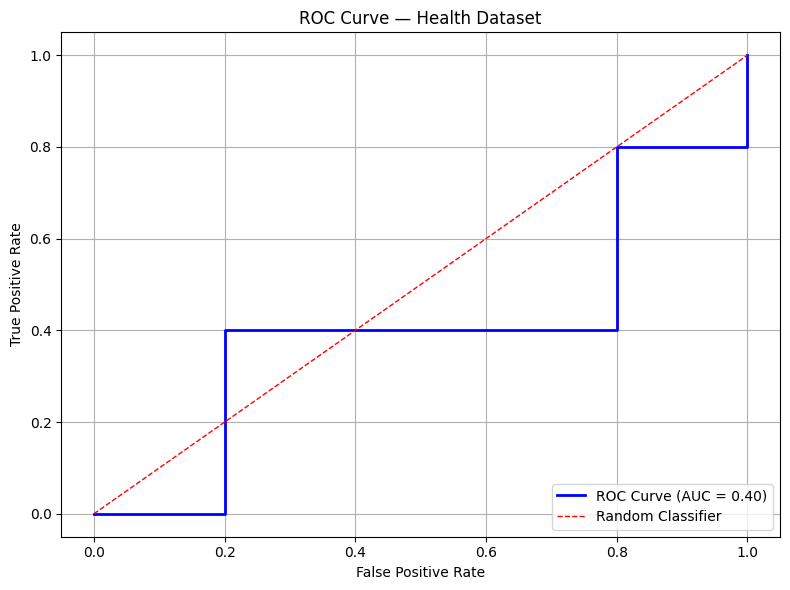

In [6]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=1, linestyle='--',
         label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Health Dataset')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

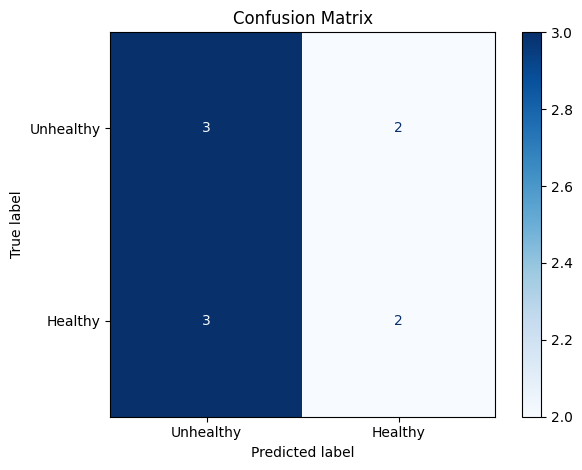

In [7]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Unhealthy', 'Healthy'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

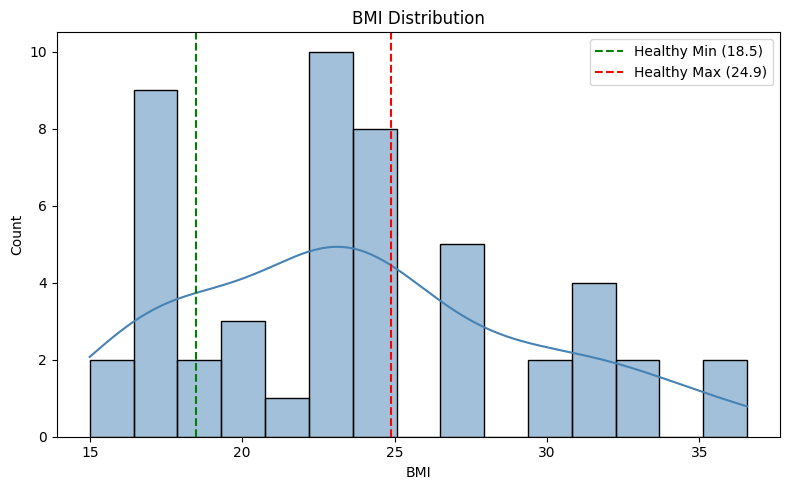

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df['BMI'], bins=15, kde=True, color='steelblue')
plt.axvline(18.5, color='green', linestyle='--', label='Healthy Min (18.5)')
plt.axvline(24.9, color='red', linestyle='--', label='Healthy Max (24.9)')
plt.xlabel('BMI')
plt.ylabel('Count')
plt.title('BMI Distribution')
plt.legend()
plt.tight_layout()
plt.show()

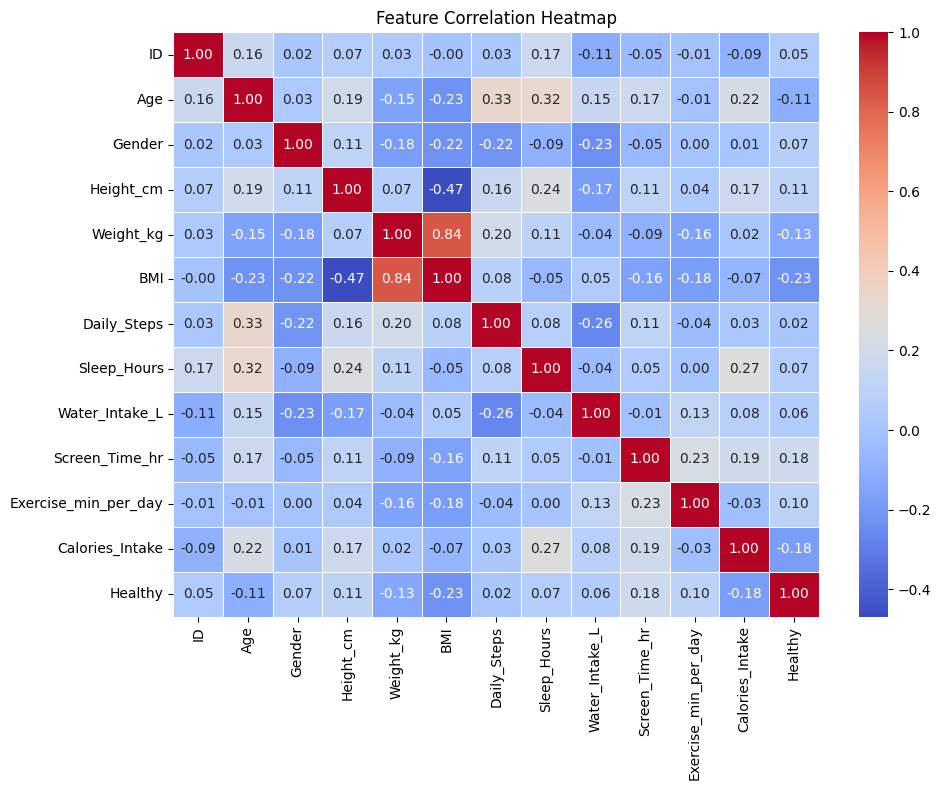

In [9]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

C:\Users\maryu\AppData\Local\Temp\ipykernel_5556\4129453725.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y=feature, data=df,
C:\Users\maryu\AppData\Local\Temp\ipykernel_5556\4129453725.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['Female', 'Male'])
C:\Users\maryu\AppData\Local\Temp\ipykernel_5556\4129453725.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Gender', y=feature, data=df,
C:\Users\maryu\AppData\Local\Temp\ipykernel_5556\4129453725.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks()

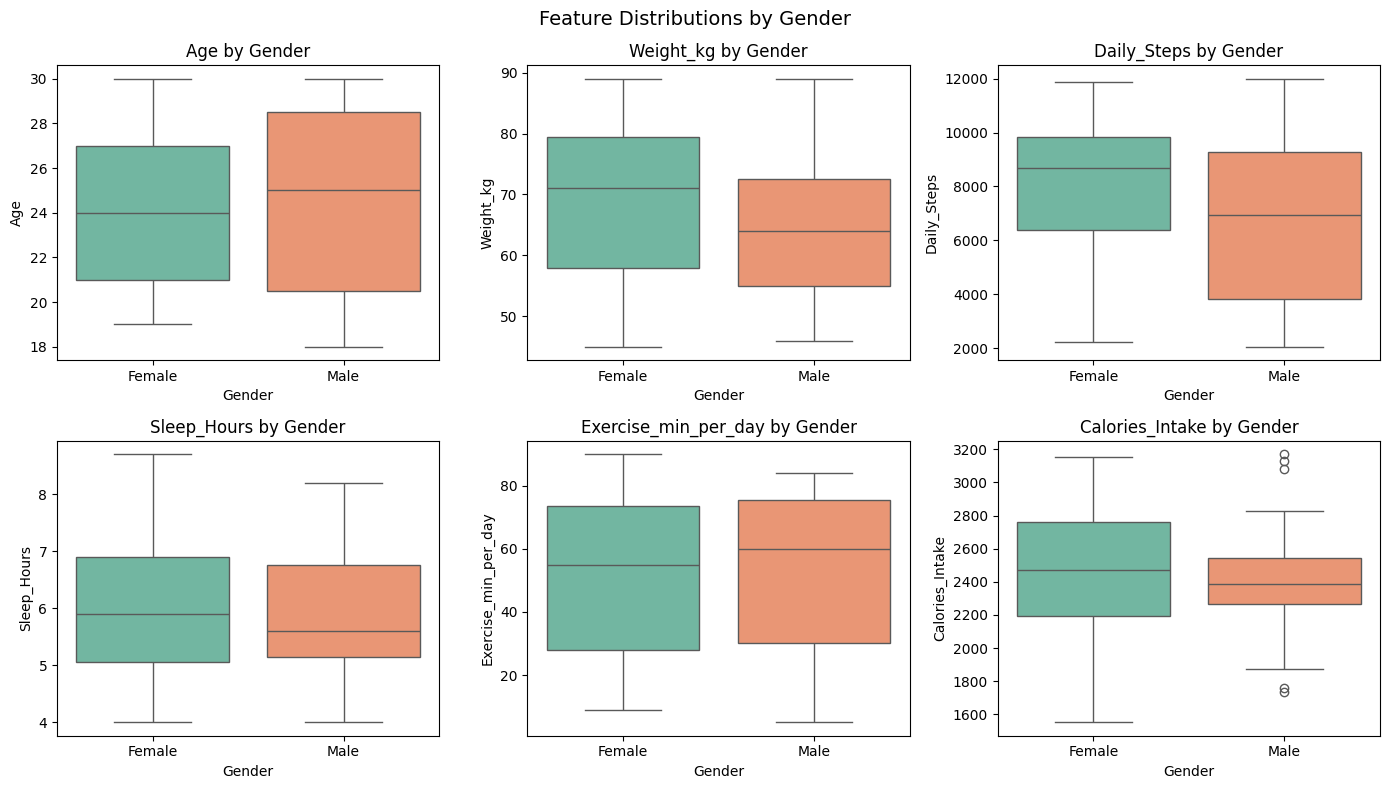

In [10]:
features = ['Age', 'Weight_kg', 'Daily_Steps', 'Sleep_Hours',
            'Exercise_min_per_day', 'Calories_Intake']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, feature in enumerate(features):
    sns.boxplot(x='Gender', y=feature, data=df,
                palette='Set2', ax=axes[i])
    axes[i].set_title(f'{feature} by Gender')
    axes[i].set_xticklabels(['Female', 'Male'])

plt.suptitle('Feature Distributions by Gender', fontsize=14)
plt.tight_layout()
plt.show()

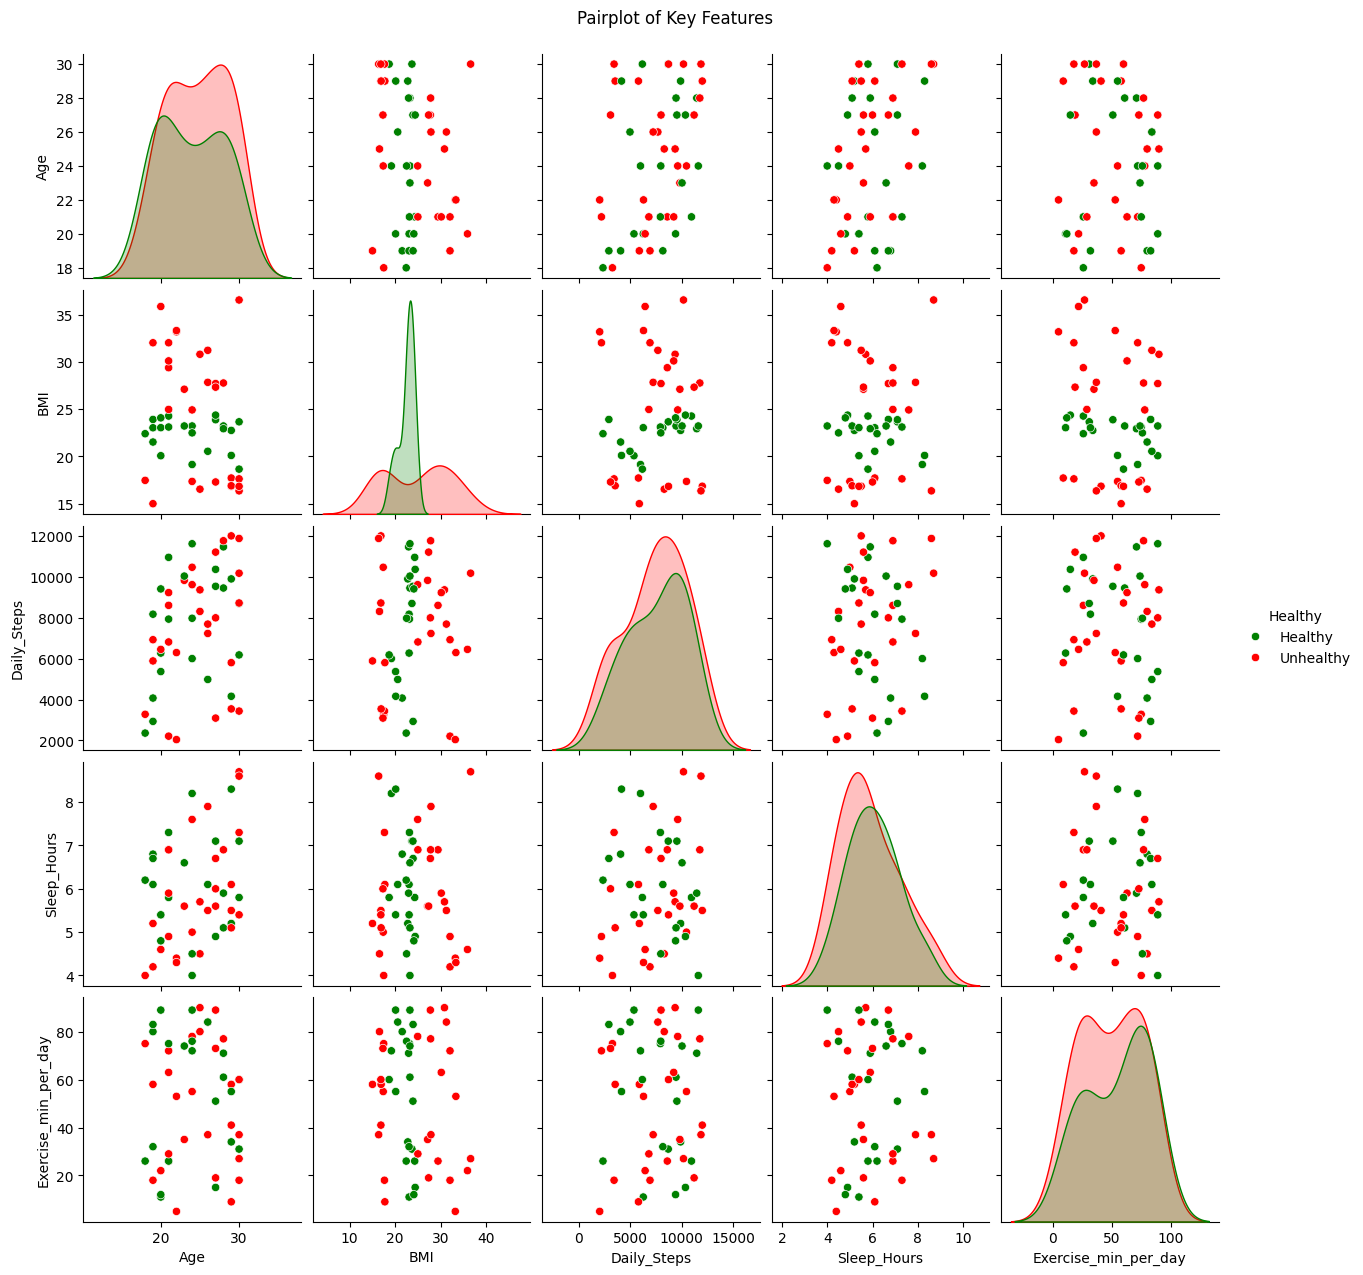

In [11]:
selected = df[['Age', 'BMI', 'Daily_Steps',
               'Sleep_Hours', 'Exercise_min_per_day', 'Healthy']].copy()
selected['Healthy'] = selected['Healthy'].map({0: 'Unhealthy', 1: 'Healthy'})

sns.pairplot(selected, hue='Healthy',
             palette={'Healthy': 'green', 'Unhealthy': 'red'})
plt.suptitle('Pairplot of Key Features', y=1.02)
plt.show()

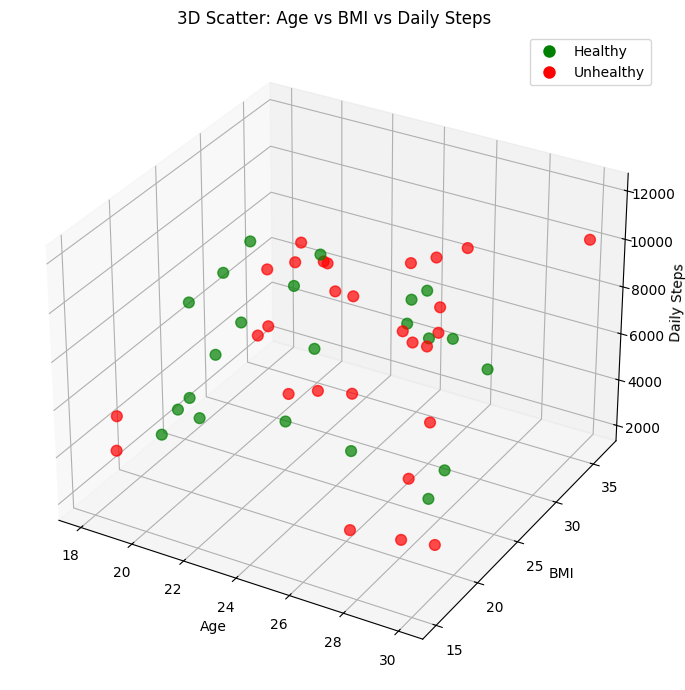

In [12]:
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

colors = df['Healthy'].map({1: 'green', 0: 'red'})

ax.scatter(df['Age'], df['BMI'], df['Daily_Steps'],
           c=colors, s=60, alpha=0.7)

ax.set_xlabel('Age')
ax.set_ylabel('BMI')
ax.set_zlabel('Daily Steps')
ax.set_title('3D Scatter: Age vs BMI vs Daily Steps')

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='green', markersize=10, label='Healthy'),
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='red', markersize=10, label='Unhealthy')
]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

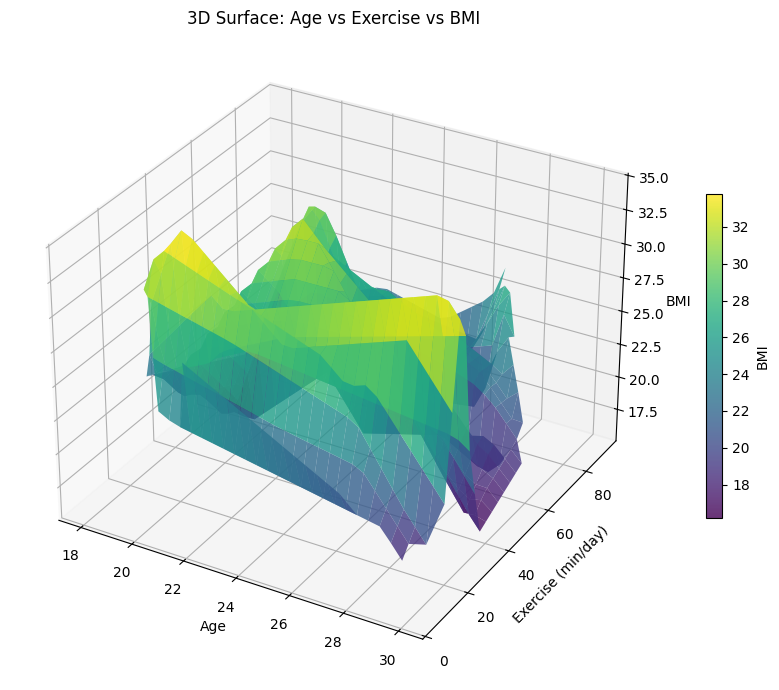

In [13]:
from scipy.interpolate import griddata

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

x = df['Age'].values
y = df['Exercise_min_per_day'].values
z = df['BMI'].values

xi = np.linspace(x.min(), x.max(), 30)
yi = np.linspace(y.min(), y.max(), 30)
xi, yi = np.meshgrid(xi, yi)
zi = griddata((x, y), z, (xi, yi), method='linear')

surf = ax.plot_surface(xi, yi, zi, cmap='viridis',
                        alpha=0.8, edgecolor='none')
fig.colorbar(surf, ax=ax, shrink=0.5, label='BMI')

ax.set_xlabel('Age')
ax.set_ylabel('Exercise (min/day)')
ax.set_zlabel('BMI')
ax.set_title('3D Surface: Age vs Exercise vs BMI')
plt.tight_layout()
plt.show()

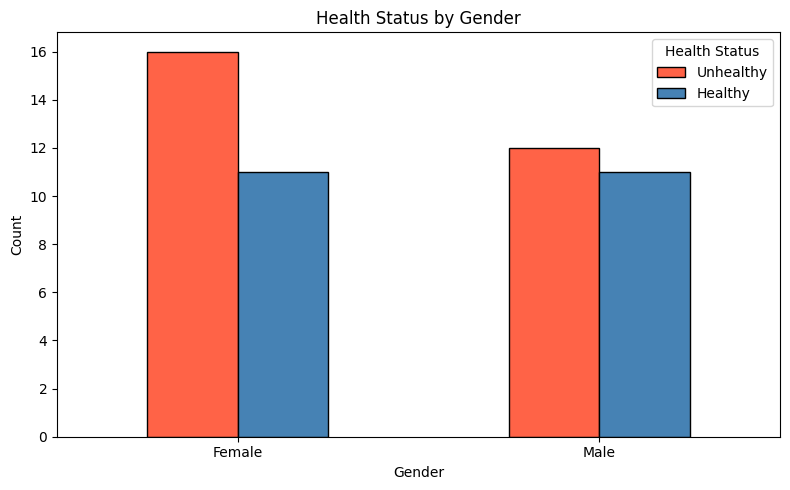

In [14]:
gender_health = df.groupby(['Gender', 'Healthy']).size().unstack()
gender_health.index = ['Female', 'Male']
gender_health.columns = ['Unhealthy', 'Healthy']

gender_health.plot(kind='bar', figsize=(8, 5),
                   color=['tomato', 'steelblue'],
                   edgecolor='black', width=0.5)

plt.title('Health Status by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='Health Status')
plt.tight_layout()
plt.show()

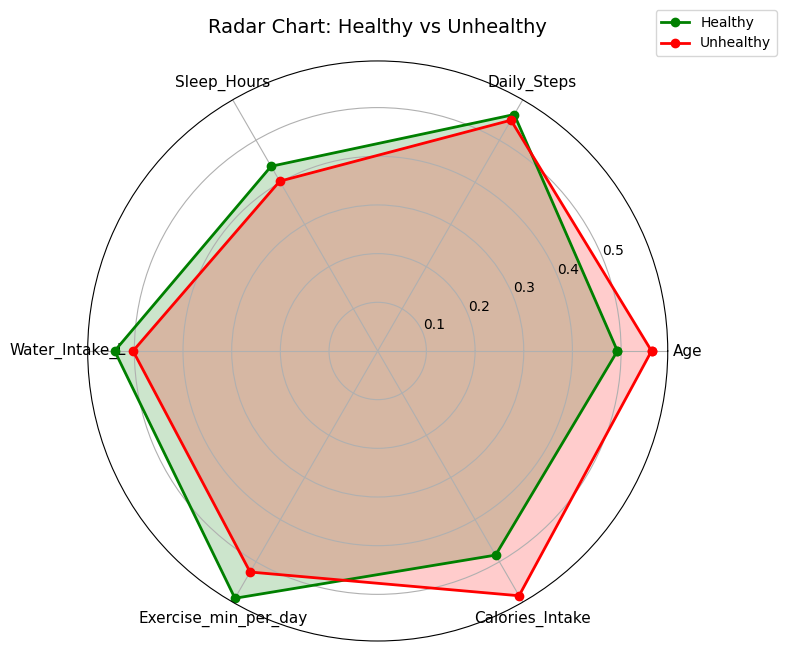

In [15]:
from matplotlib.patches import FancyArrowPatch

categories = ['Age', 'Daily_Steps', 'Sleep_Hours',
              'Water_Intake_L', 'Exercise_min_per_day', 'Calories_Intake']

# Normalize data for radar
df_norm = df.copy()
for col in categories:
    df_norm[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

healthy_avg = df_norm[df_norm['Healthy']==1][categories].mean().tolist()
unhealthy_avg = df_norm[df_norm['Healthy']==0][categories].mean().tolist()

# Close the radar shape
healthy_avg += healthy_avg[:1]
unhealthy_avg += unhealthy_avg[:1]

N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8),
                        subplot_kw=dict(polar=True))

ax.plot(angles, healthy_avg, 'o-', linewidth=2,
        color='green', label='Healthy')
ax.fill(angles, healthy_avg, alpha=0.2, color='green')

ax.plot(angles, unhealthy_avg, 'o-', linewidth=2,
        color='red', label='Unhealthy')
ax.fill(angles, unhealthy_avg, alpha=0.2, color='red')

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_title('Radar Chart: Healthy vs Unhealthy', size=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.1))
plt.tight_layout()
plt.show()

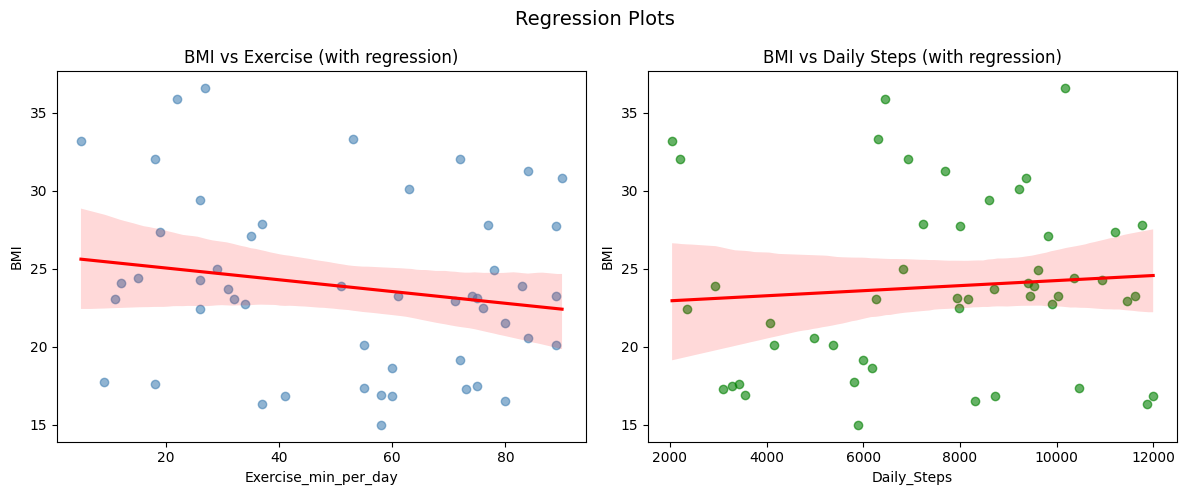

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1 — BMI vs Exercise
sns.regplot(x='Exercise_min_per_day', y='BMI',
            data=df, ax=axes[0],
            scatter_kws={'color': 'steelblue', 'alpha': 0.6},
            line_kws={'color': 'red'})
axes[0].set_title('BMI vs Exercise (with regression)')

# Plot 2 — BMI vs Daily Steps
sns.regplot(x='Daily_Steps', y='BMI',
            data=df, ax=axes[1],
            scatter_kws={'color': 'green', 'alpha': 0.6},
            line_kws={'color': 'red'})
axes[1].set_title('BMI vs Daily Steps (with regression)')

plt.suptitle('Regression Plots', fontsize=14)
plt.tight_layout()
plt.show()

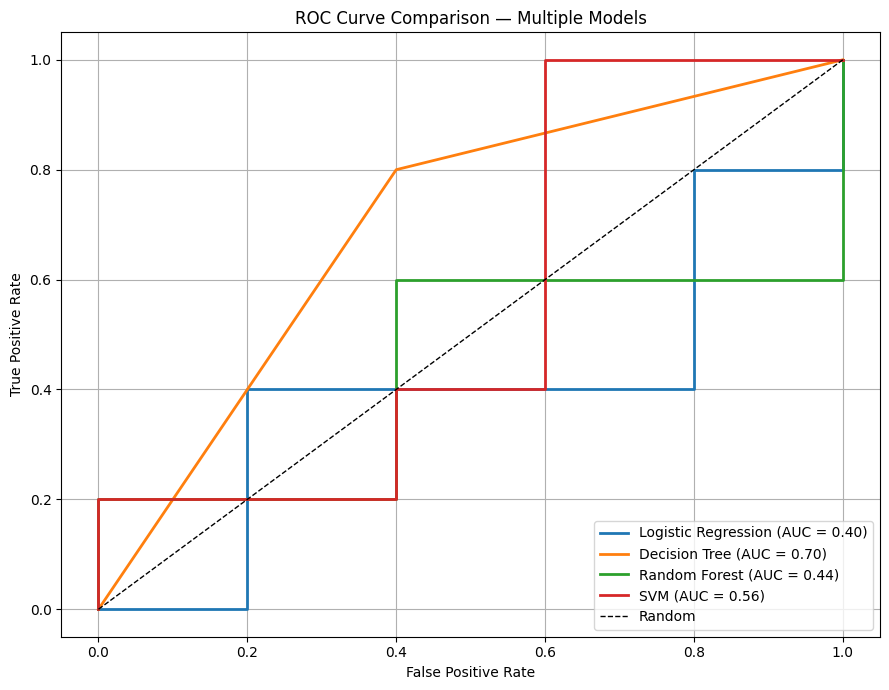

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

plt.figure(figsize=(9, 7))

for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_prob_model = clf.predict_proba(X_test)[:, 1]
    fpr_m, tpr_m, _ = roc_curve(y_test, y_prob_model)
    auc_m = auc(fpr_m, tpr_m)
    plt.plot(fpr_m, tpr_m, lw=2,
             label=f'{name} (AUC = {auc_m:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison — Multiple Models')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

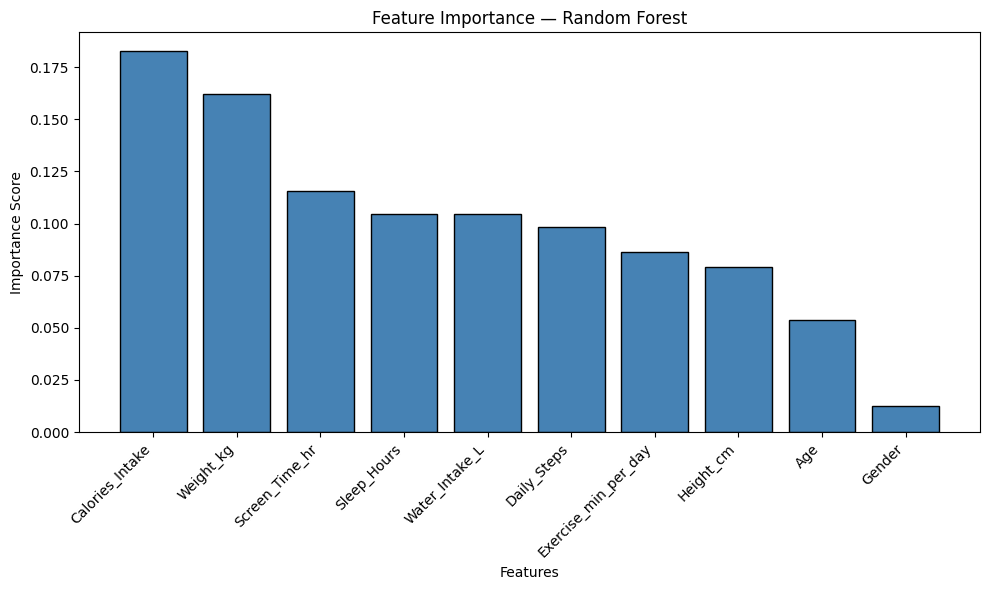

In [19]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

feature_names = df.drop(columns=['ID', 'Healthy', 'BMI']).columns
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)),
        importances[indices],
        color='steelblue', edgecolor='black')
plt.xticks(range(len(importances)),
           [feature_names[i] for i in indices],
           rotation=45, ha='right')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.title('Feature Importance — Random Forest')
plt.tight_layout()
plt.show()

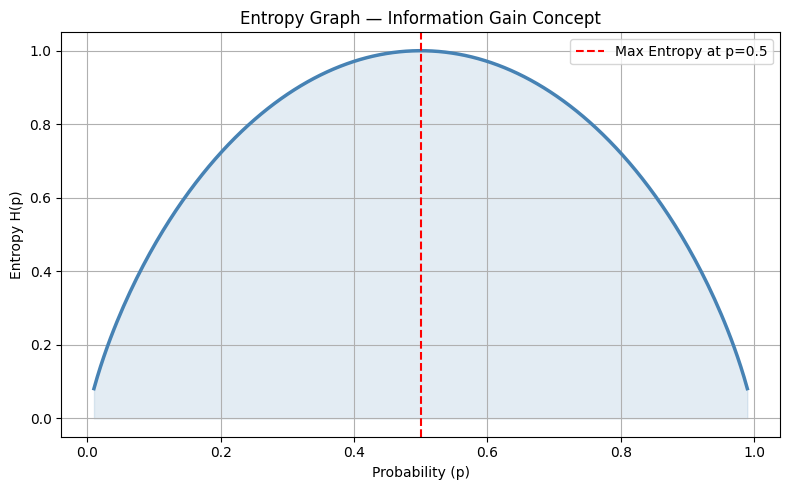

In [20]:
# Entropy formula: H = -p*log2(p) - (1-p)*log2(1-p)

p_values = np.linspace(0.01, 0.99, 200)
entropy = -p_values * np.log2(p_values) - (1 - p_values) * np.log2(1 - p_values)

plt.figure(figsize=(8, 5))
plt.plot(p_values, entropy, color='steelblue', linewidth=2.5)
plt.fill_between(p_values, entropy, alpha=0.15, color='steelblue')
plt.axvline(0.5, color='red', linestyle='--', label='Max Entropy at p=0.5')
plt.xlabel('Probability (p)')
plt.ylabel('Entropy H(p)')
plt.title('Entropy Graph — Information Gain Concept')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

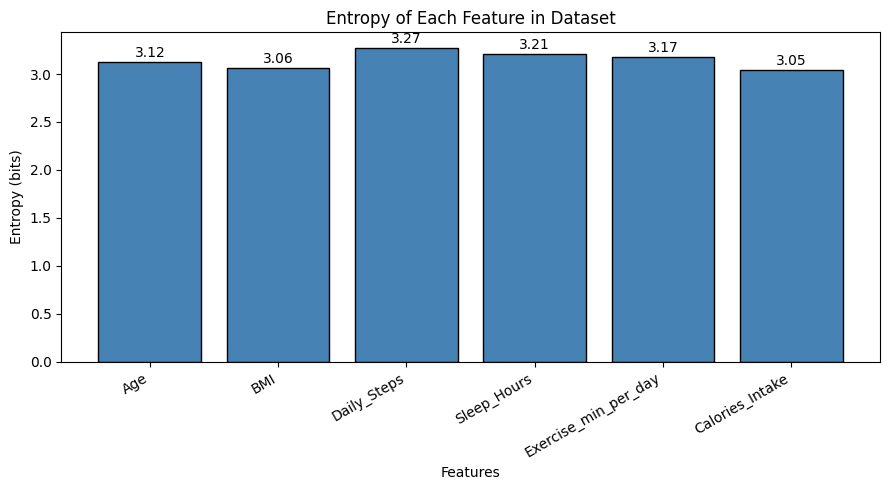

In [21]:
from scipy.stats import entropy as scipy_entropy

features_to_check = ['Age', 'BMI', 'Daily_Steps',
                     'Sleep_Hours', 'Exercise_min_per_day',
                     'Calories_Intake']

entropies = []
for col in features_to_check:
    # Bin continuous data into 10 bins
    counts, _ = np.histogram(df[col], bins=10)
    counts = counts[counts > 0]  # remove zeros
    probs = counts / counts.sum()
    ent = scipy_entropy(probs, base=2)
    entropies.append(ent)

plt.figure(figsize=(9, 5))
bars = plt.bar(features_to_check, entropies,
               color='steelblue', edgecolor='black')

# Add value labels on bars
for bar, val in zip(bars, entropies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', va='bottom', fontsize=10)

plt.xlabel('Features')
plt.ylabel('Entropy (bits)')
plt.title('Entropy of Each Feature in Dataset')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

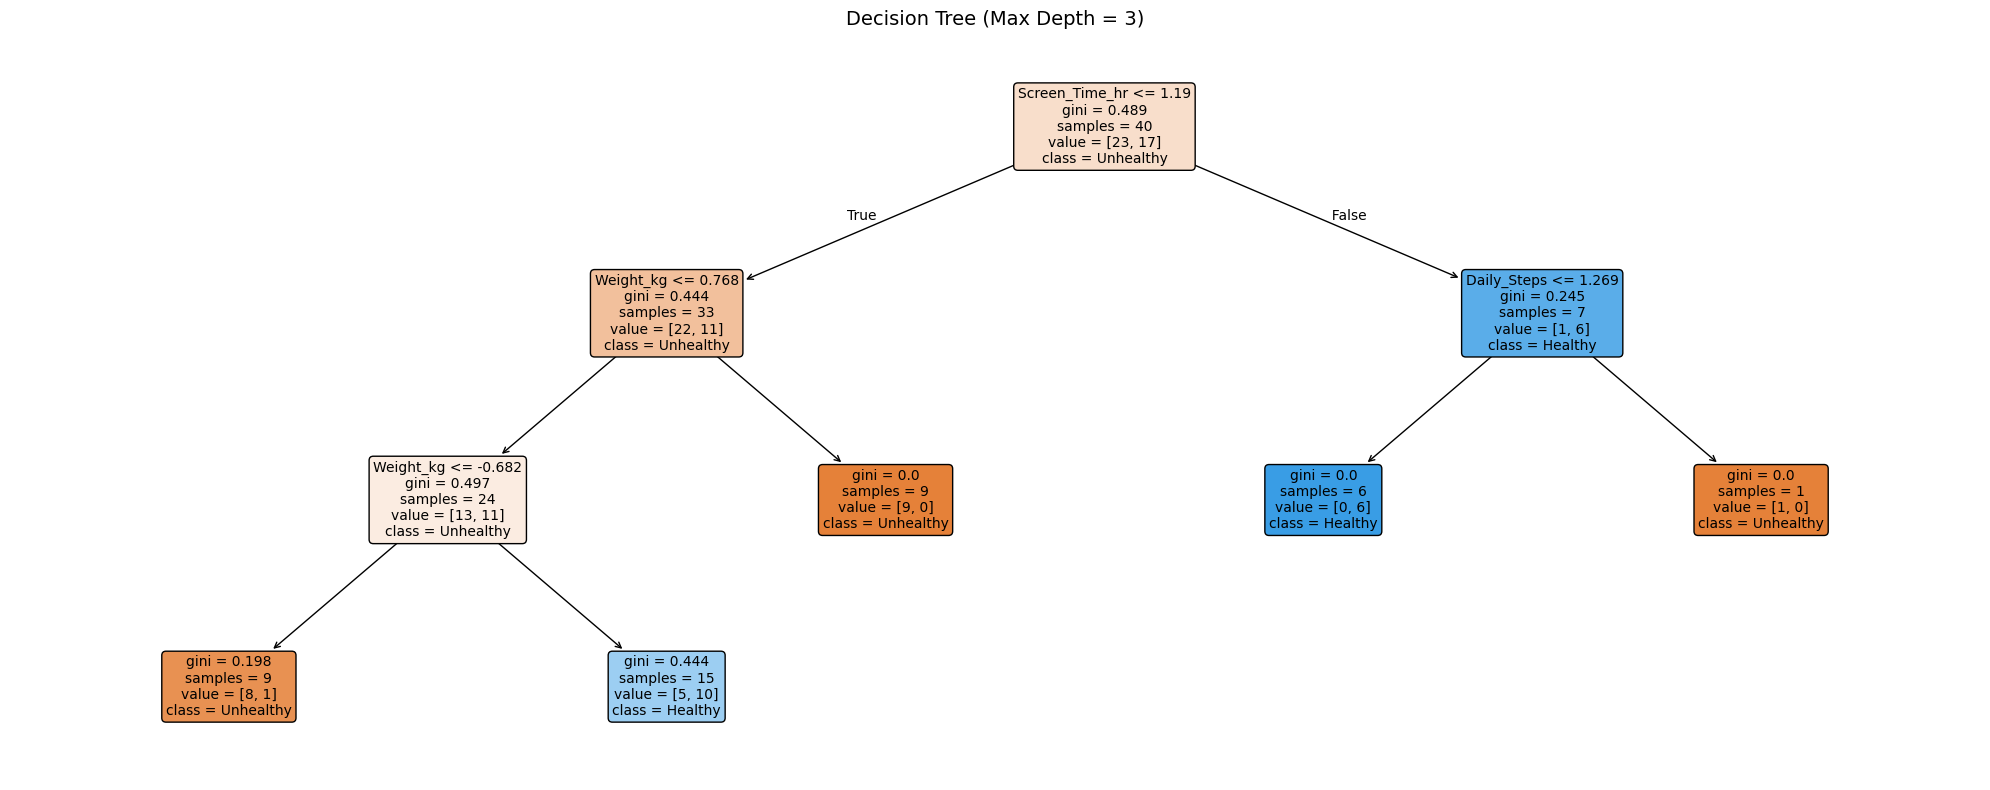

In [22]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Train Decision Tree
dt = DecisionTreeClassifier(max_depth=3, random_state=42)
dt.fit(X_train, y_train)

# Plot the tree
plt.figure(figsize=(20, 8))
feature_names = list(df.drop(columns=['ID', 'Healthy', 'BMI']).columns)
plot_tree(dt,
          feature_names=feature_names,
          class_names=['Unhealthy', 'Healthy'],
          filled=True,
          rounded=True,
          fontsize=10)
plt.title('Decision Tree (Max Depth = 3)', fontsize=14)
plt.tight_layout()
plt.show()

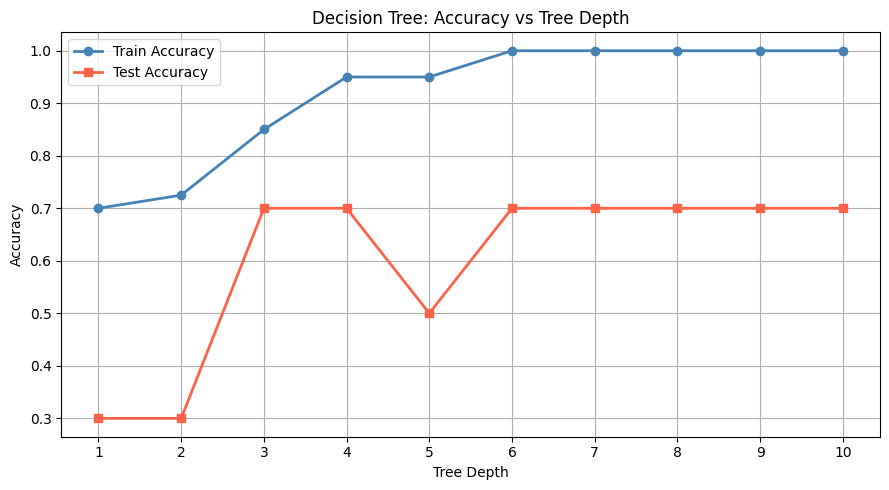

In [23]:
from sklearn.metrics import accuracy_score

train_acc = []
test_acc = []
depths = range(1, 11)

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, clf.predict(X_train)))
    test_acc.append(accuracy_score(y_test, clf.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(depths, train_acc, 'o-', color='steelblue',
         linewidth=2, label='Train Accuracy')
plt.plot(depths, test_acc, 's-', color='tomato',
         linewidth=2, label='Test Accuracy')
plt.xlabel('Tree Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree: Accuracy vs Tree Depth')
plt.legend()
plt.grid(True)
plt.xticks(depths)
plt.tight_layout()
plt.show()

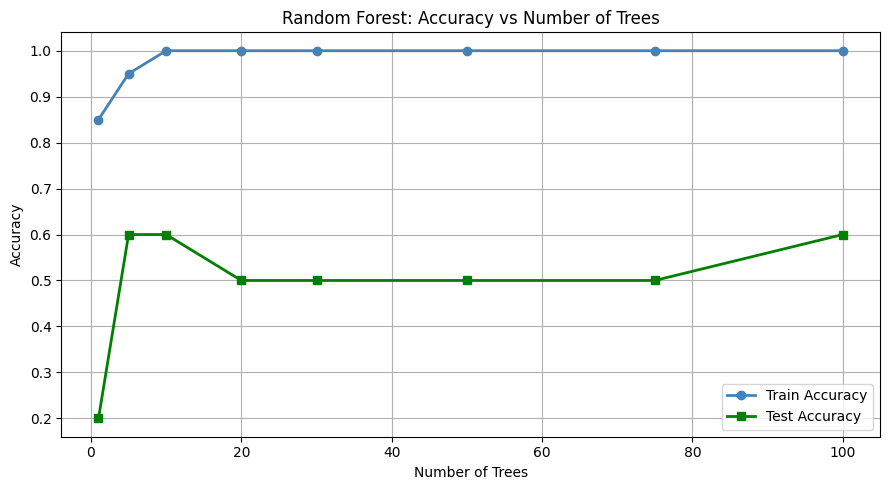

In [24]:
from sklearn.ensemble import RandomForestClassifier

train_acc_rf = []
test_acc_rf = []
n_trees = [1, 5, 10, 20, 30, 50, 75, 100]

for n in n_trees:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    train_acc_rf.append(accuracy_score(y_train, rf.predict(X_train)))
    test_acc_rf.append(accuracy_score(y_test, rf.predict(X_test)))

plt.figure(figsize=(9, 5))
plt.plot(n_trees, train_acc_rf, 'o-', color='steelblue',
         linewidth=2, label='Train Accuracy')
plt.plot(n_trees, test_acc_rf, 's-', color='green',
         linewidth=2, label='Test Accuracy')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.title('Random Forest: Accuracy vs Number of Trees')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

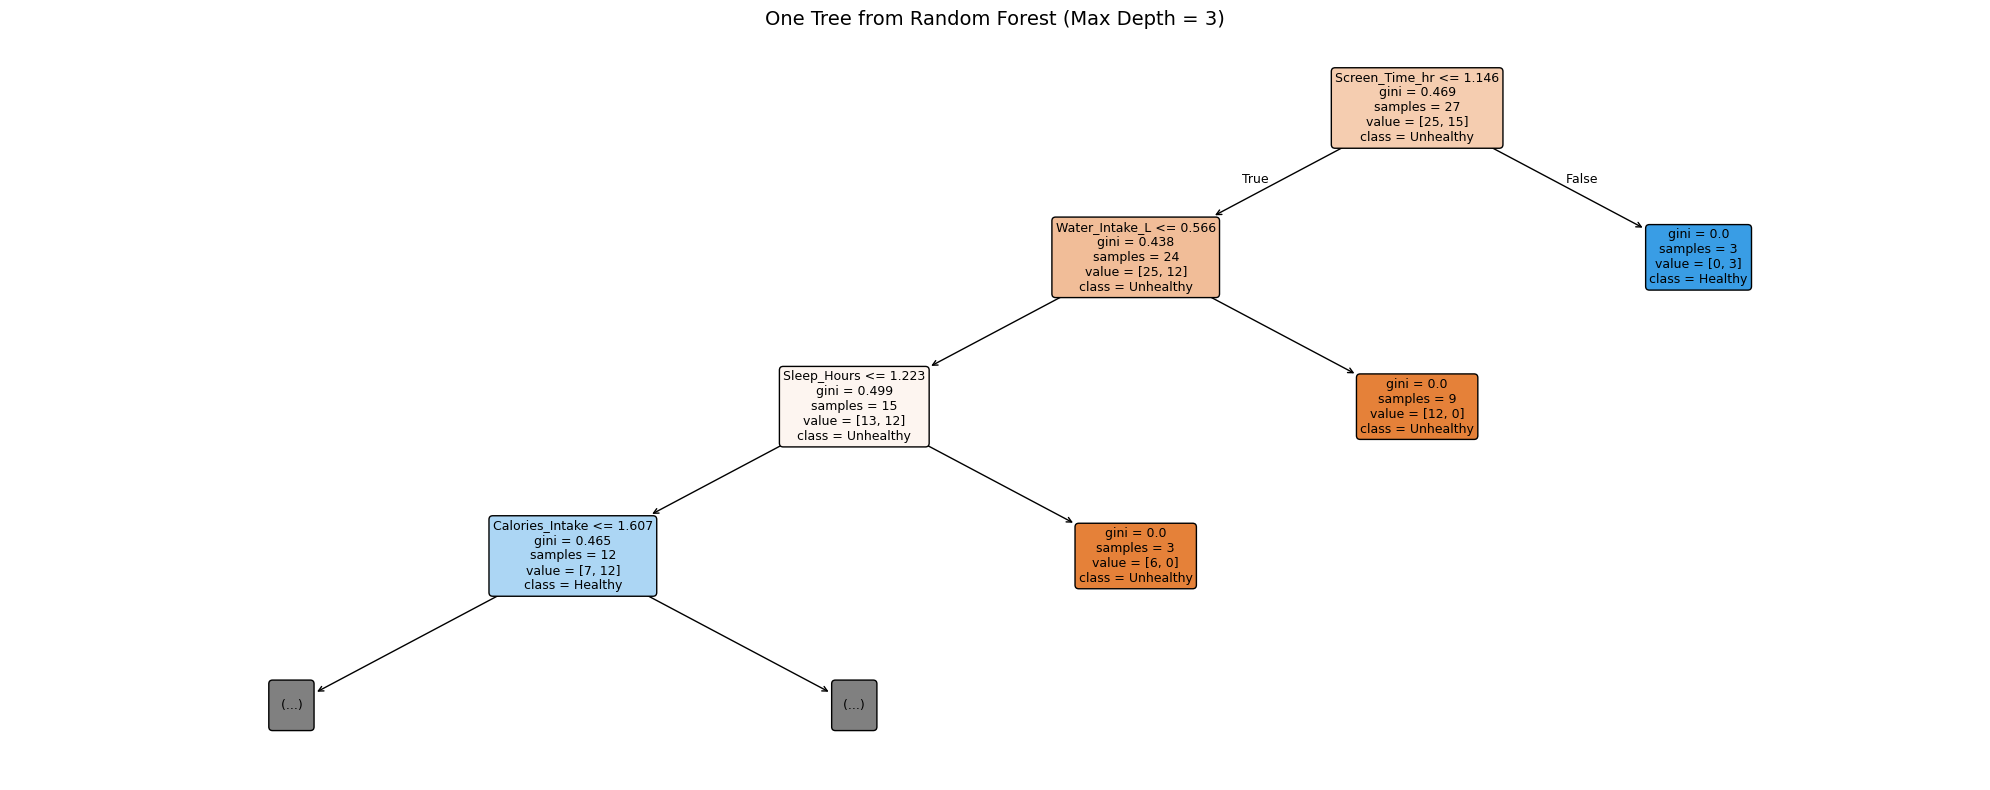

In [25]:
# Visualize one tree from inside Random Forest
rf_model = RandomForestClassifier(n_estimators=10, random_state=42)
rf_model.fit(X_train, y_train)

# Pick first tree from forest
single_tree = rf_model.estimators_[0]

plt.figure(figsize=(20, 8))
plot_tree(single_tree,
          feature_names=feature_names,
          class_names=['Unhealthy', 'Healthy'],
          filled=True,
          rounded=True,
          max_depth=3,
          fontsize=9)
plt.title('One Tree from Random Forest (Max Depth = 3)', fontsize=14)
plt.tight_layout()
plt.show()

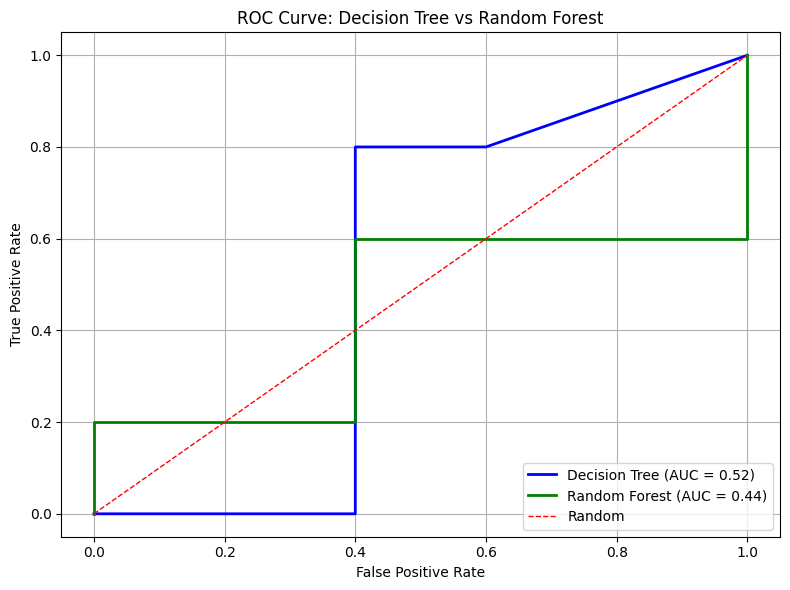

In [26]:
dt_model = DecisionTreeClassifier(max_depth=3, random_state=42)
rf_model2 = RandomForestClassifier(n_estimators=100, random_state=42)

dt_model.fit(X_train, y_train)
rf_model2.fit(X_train, y_train)

dt_prob = dt_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model2.predict_proba(X_test)[:, 1]

fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)

auc_dt = auc(fpr_dt, tpr_dt)
auc_rf = auc(fpr_rf, tpr_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_dt, tpr_dt, 'b-', lw=2,
         label=f'Decision Tree (AUC = {auc_dt:.2f})')
plt.plot(fpr_rf, tpr_rf, 'g-', lw=2,
         label=f'Random Forest (AUC = {auc_rf:.2f})')
plt.plot([0, 1], [0, 1], 'r--', lw=1, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve: Decision Tree vs Random Forest')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()

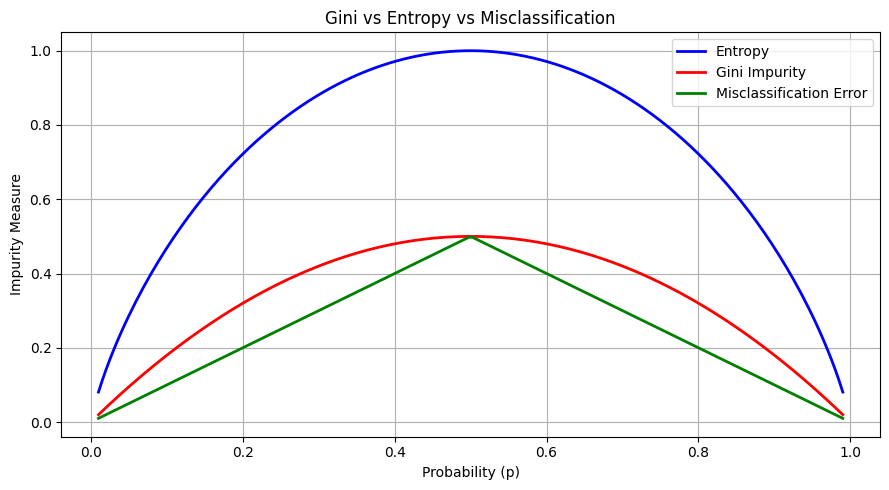

In [27]:
p = np.linspace(0.01, 0.99, 200)

gini = 2 * p * (1 - p)
entropy_vals = -p * np.log2(p) - (1 - p) * np.log2(1 - p)
misclass = 1 - np.maximum(p, 1 - p)

plt.figure(figsize=(9, 5))
plt.plot(p, entropy_vals, 'b-', lw=2, label='Entropy')
plt.plot(p, gini, 'r-', lw=2, label='Gini Impurity')
plt.plot(p, misclass, 'g-', lw=2, label='Misclassification Error')
plt.xlabel('Probability (p)')
plt.ylabel('Impurity Measure')
plt.title('Gini vs Entropy vs Misclassification')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\maryu\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\maryu\AppData\Local\Temp\ipykernel_5556\3424387266.py:211: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax6.set_xticklabels(sorted_feat, rotation=30, ha='right', fontsize=10)
C:\Users\maryu\AppData\Local\Programs\Python\Python314\Lib\site-packages\seaborn\utils.py:61: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
C:\Users\maryu\AppData\Local\Temp\ipykernel_5556\3424387266.py:281: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) DejaVu Sans.
  plt.savefig('ml_dashboard.png', dpi=150,
C:\Users\maryu\AppData\Local\Programs\Python\Python314\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127973 (\N{HOSPITAL}) missing from font(s) 

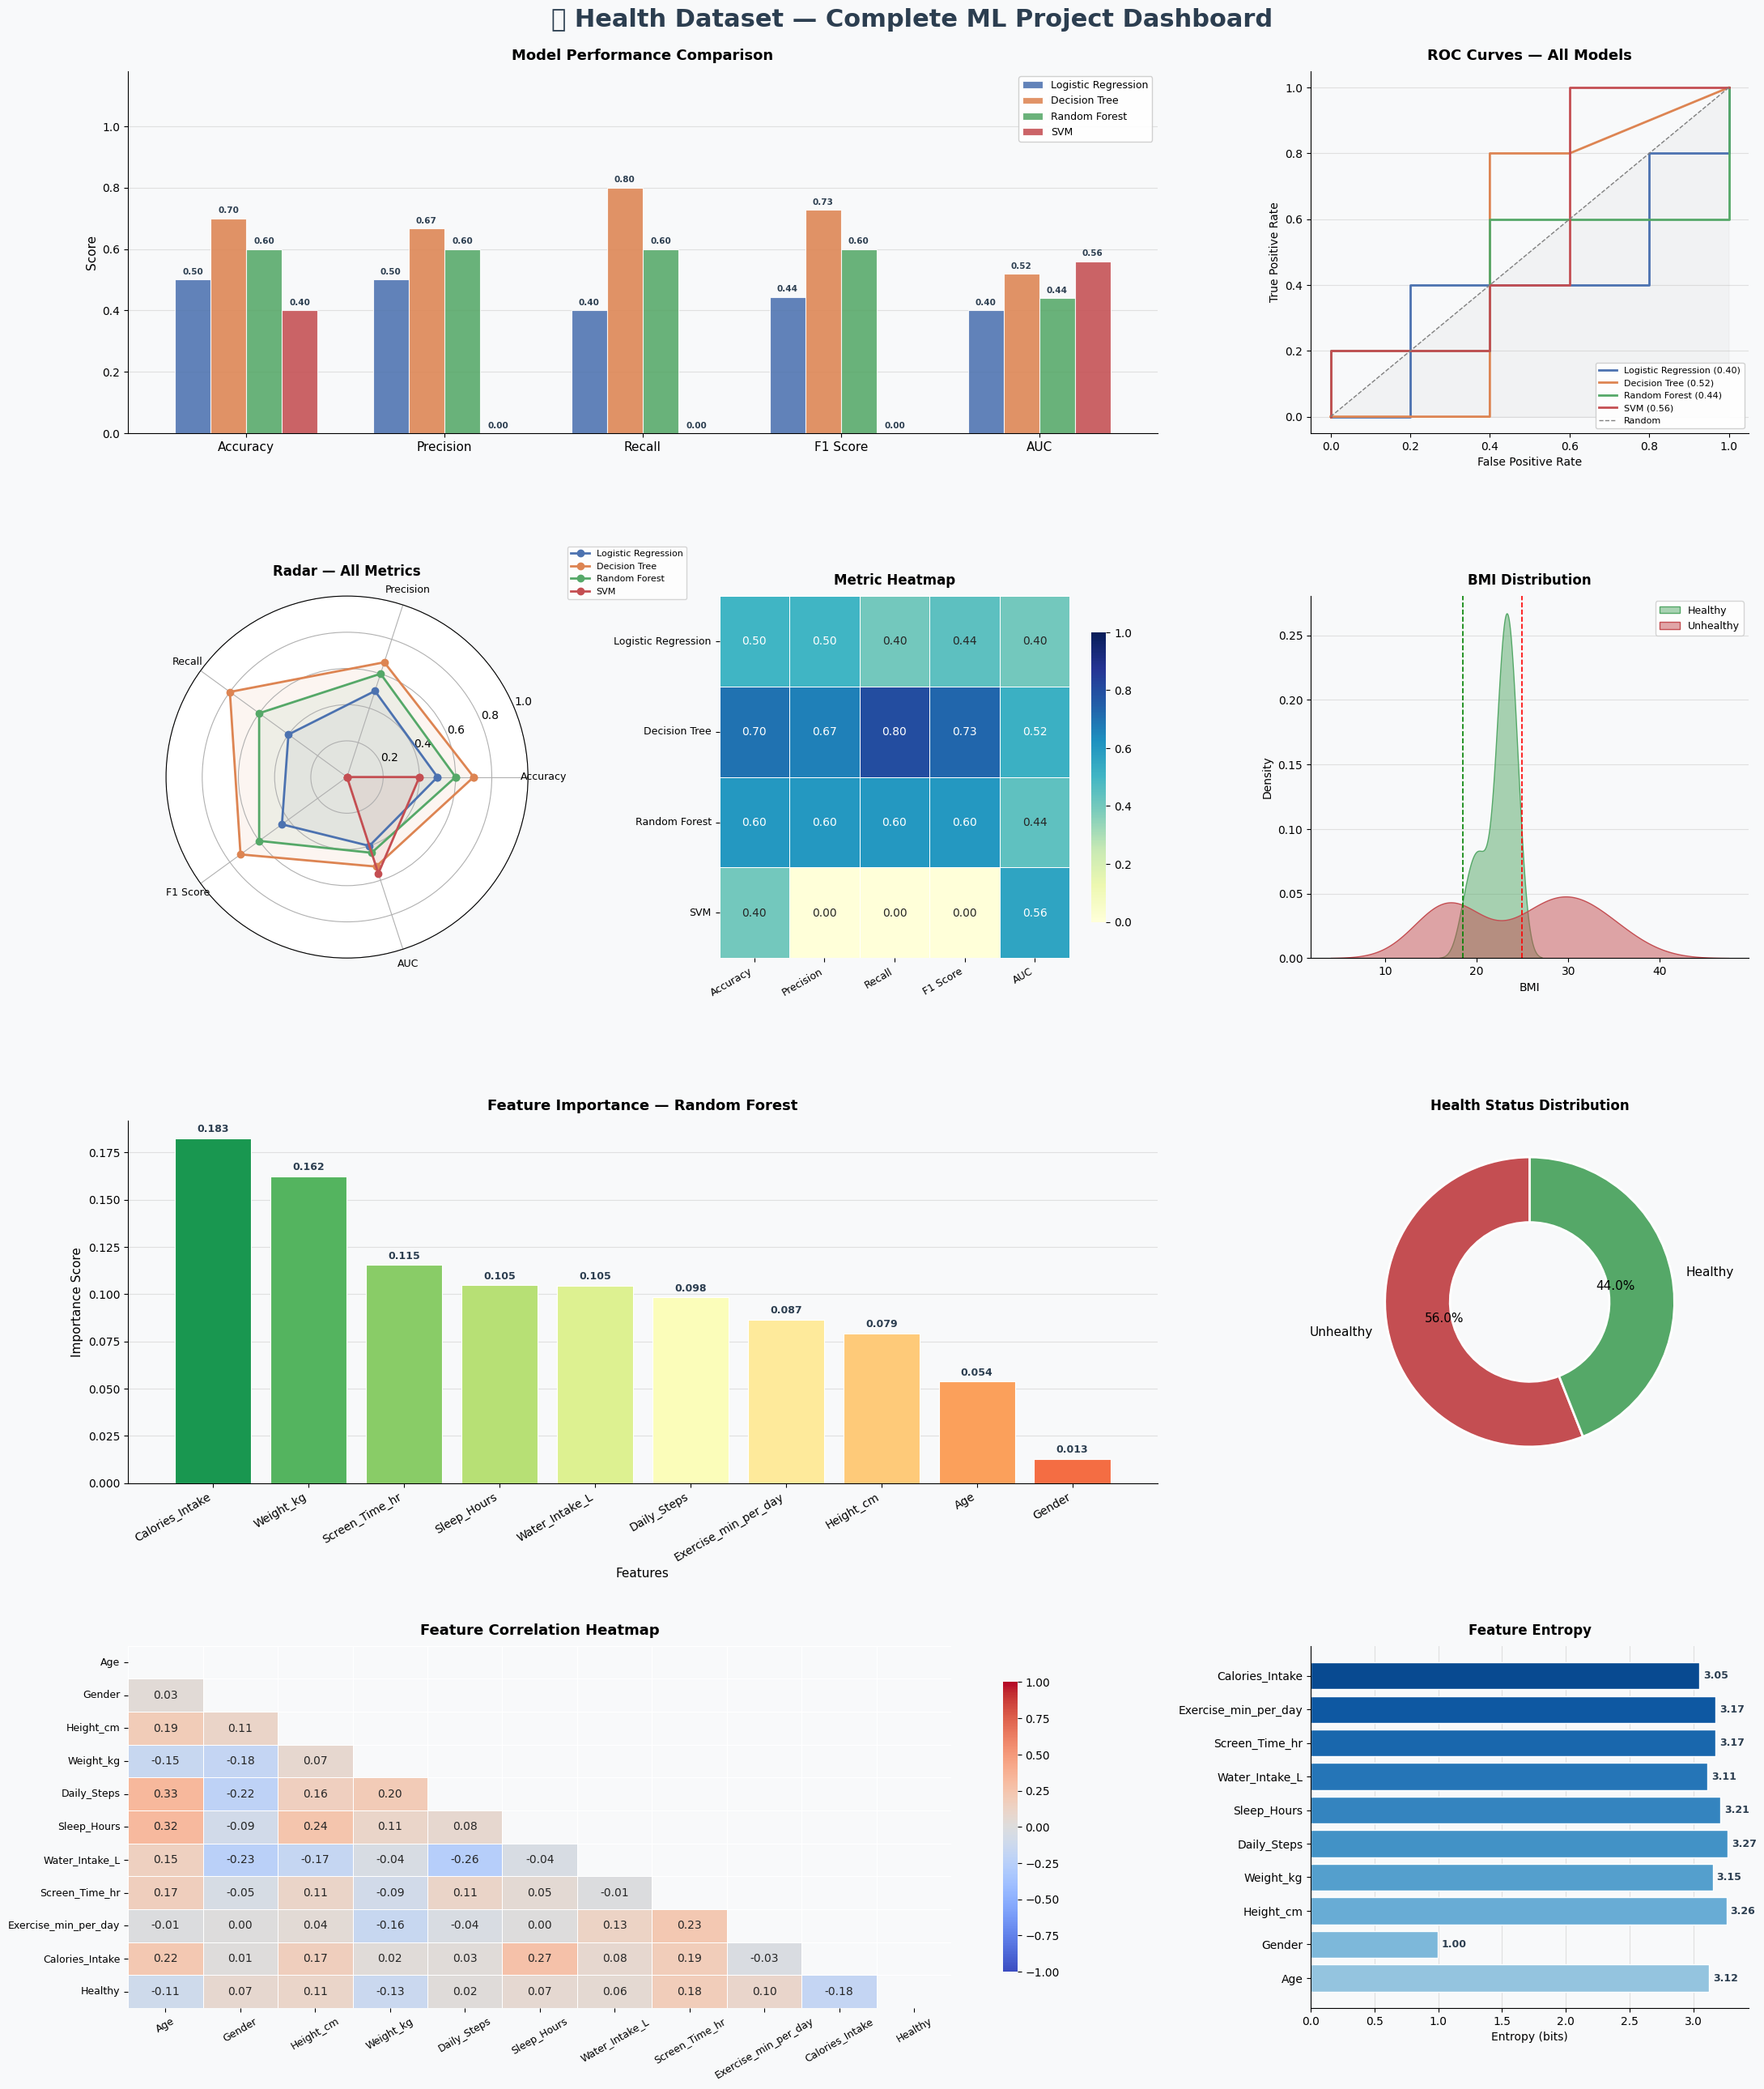

Dashboard saved as ml_dashboard.png ✅


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (roc_curve, auc, accuracy_score,
                              precision_score, recall_score, f1_score)

# ── DATA PREP ──────────────────────────────────────────────
df = pd.read_csv('health_dataset_50_records.csv')
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
df['Healthy'] = df['BMI'].apply(lambda x: 1 if 18.5 <= x <= 24.9 else 0)

X = df.drop(columns=['ID', 'Healthy', 'BMI'])
y = df['Healthy']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

feature_names = list(X.columns)

# ── TRAIN MODELS ───────────────────────────────────────────
models = {
    'Logistic\nRegression': LogisticRegression(random_state=42),
    'Decision\nTree':       DecisionTreeClassifier(max_depth=3, random_state=42),
    'Random\nForest':       RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM':                  SVC(probability=True, random_state=42)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_prob  = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    results[name] = {
        'model':     model,
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall':    recall_score(y_test, y_pred, zero_division=0),
        'f1':        f1_score(y_test, y_pred, zero_division=0),
        'auc':       auc(fpr, tpr),
        'fpr':       fpr,
        'tpr':       tpr,
        'y_pred':    y_pred
    }

# ── COLOUR PALETTE ─────────────────────────────────────────
COLORS  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
PALETTE = dict(zip(models.keys(), COLORS))
BG      = '#F8F9FA'
GRID    = '#E0E0E0'

# ── FIGURE LAYOUT ──────────────────────────────────────────
fig = plt.figure(figsize=(22, 26), facecolor=BG)
fig.suptitle('🏥 Health Dataset — Complete ML Project Dashboard',
             fontsize=22, fontweight='bold', y=0.98, color='#2C3E50')

gs = fig.add_gridspec(4, 3, hspace=0.45, wspace=0.35,
                      left=0.06, right=0.97, top=0.95, bottom=0.03)

model_names = list(results.keys())
metrics     = ['accuracy', 'precision', 'recall', 'f1', 'auc']
metric_labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC']

# ══════════════════════════════════════════════════════════
# PLOT 1 — Grouped Metric Comparison Bar Chart
# ══════════════════════════════════════════════════════════
ax1 = fig.add_subplot(gs[0, :2])
ax1.set_facecolor(BG)

x      = np.arange(len(metrics))
width  = 0.18

for i, (name, color) in enumerate(zip(model_names, COLORS)):
    vals = [results[name][m] for m in metrics]
    bars = ax1.bar(x + i * width, vals, width,
                   label=name.replace('\n', ' '),
                   color=color, alpha=0.88, edgecolor='white', linewidth=0.8)
    for bar, v in zip(bars, vals):
        ax1.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.012,
                 f'{v:.2f}', ha='center', va='bottom',
                 fontsize=7.5, fontweight='bold', color='#2C3E50')

ax1.set_xticks(x + width * 1.5)
ax1.set_xticklabels(metric_labels, fontsize=11)
ax1.set_ylim(0, 1.18)
ax1.set_ylabel('Score', fontsize=11)
ax1.set_title('Model Performance Comparison', fontsize=13, fontweight='bold', pad=10)
ax1.legend(loc='upper right', fontsize=9, framealpha=0.9)
ax1.yaxis.grid(True, color=GRID, linewidth=0.8)
ax1.set_axisbelow(True)
ax1.spines[['top','right']].set_visible(False)

# ══════════════════════════════════════════════════════════
# PLOT 2 — ROC Curves
# ══════════════════════════════════════════════════════════
ax2 = fig.add_subplot(gs[0, 2])
ax2.set_facecolor(BG)

for (name, res), color in zip(results.items(), COLORS):
    label = name.replace('\n', ' ')
    ax2.plot(res['fpr'], res['tpr'], lw=2, color=color,
             label=f"{label} ({res['auc']:.2f})")

ax2.plot([0,1],[0,1],'--', color='gray', lw=1, label='Random')
ax2.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax2.set_xlabel('False Positive Rate', fontsize=10)
ax2.set_ylabel('True Positive Rate', fontsize=10)
ax2.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold', pad=10)
ax2.legend(fontsize=8, loc='lower right', framealpha=0.9)
ax2.yaxis.grid(True, color=GRID, linewidth=0.8)
ax2.set_axisbelow(True)
ax2.spines[['top','right']].set_visible(False)

# ══════════════════════════════════════════════════════════
# PLOT 3 — Radar Chart
# ══════════════════════════════════════════════════════════
ax3 = fig.add_subplot(gs[1, 0], polar=True)

N      = len(metrics)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

for (name, res), color in zip(results.items(), COLORS):
    vals = [res[m] for m in metrics] + [res[metrics[0]]]
    ax3.plot(angles, vals, 'o-', lw=2, color=color,
             label=name.replace('\n',' '))
    ax3.fill(angles, vals, alpha=0.08, color=color)

ax3.set_xticks(angles[:-1])
ax3.set_xticklabels(metric_labels, fontsize=9)
ax3.set_ylim(0, 1)
ax3.set_title('Radar — All Metrics', fontsize=12,
              fontweight='bold', pad=18)
ax3.legend(loc='upper right',
           bbox_to_anchor=(1.45, 1.15), fontsize=8)

# ══════════════════════════════════════════════════════════
# PLOT 4 — Heatmap of Metrics
# ══════════════════════════════════════════════════════════
ax4 = fig.add_subplot(gs[1, 1])
ax4.set_facecolor(BG)

heat_data = pd.DataFrame(
    {m: [results[n][m] for n in model_names] for m in metrics},
    index=[n.replace('\n',' ') for n in model_names]
)

sns.heatmap(heat_data, annot=True, fmt='.2f', cmap='YlGnBu',
            linewidths=0.5, ax=ax4, vmin=0, vmax=1,
            cbar_kws={'shrink': 0.8})
ax4.set_title('Metric Heatmap', fontsize=12, fontweight='bold', pad=10)
ax4.set_xticklabels(metric_labels, rotation=30, ha='right', fontsize=9)
ax4.set_yticklabels(ax4.get_yticklabels(), rotation=0, fontsize=9)

# ══════════════════════════════════════════════════════════
# PLOT 5 — BMI Distribution (Healthy vs Unhealthy)
# ══════════════════════════════════════════════════════════
ax5 = fig.add_subplot(gs[1, 2])
ax5.set_facecolor(BG)

sns.kdeplot(df[df['Healthy']==1]['BMI'], ax=ax5,
            fill=True, color='#55A868', alpha=0.5, label='Healthy')
sns.kdeplot(df[df['Healthy']==0]['BMI'], ax=ax5,
            fill=True, color='#C44E52', alpha=0.5, label='Unhealthy')
ax5.axvline(18.5, color='green', linestyle='--', linewidth=1.2)
ax5.axvline(24.9, color='red',   linestyle='--', linewidth=1.2)
ax5.set_xlabel('BMI', fontsize=10)
ax5.set_ylabel('Density', fontsize=10)
ax5.set_title('BMI Distribution', fontsize=12, fontweight='bold', pad=10)
ax5.legend(fontsize=9)
ax5.yaxis.grid(True, color=GRID, linewidth=0.8)
ax5.set_axisbelow(True)
ax5.spines[['top','right']].set_visible(False)

# ══════════════════════════════════════════════════════════
# PLOT 6 — Feature Importance (Random Forest)
# ══════════════════════════════════════════════════════════
ax6 = fig.add_subplot(gs[2, :2])
ax6.set_facecolor(BG)

rf_model = results['Random\nForest']['model']
importances = rf_model.feature_importances_
indices     = np.argsort(importances)[::-1]
sorted_feat = [feature_names[i] for i in indices]
sorted_imp  = importances[indices]

bar_colors = plt.cm.RdYlGn(np.linspace(0.2, 0.9, len(sorted_feat)))[::-1]
bars = ax6.bar(sorted_feat, sorted_imp,
               color=bar_colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, sorted_imp):
    ax6.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', va='bottom',
             fontsize=9, fontweight='bold', color='#2C3E50')

ax6.set_xlabel('Features', fontsize=11)
ax6.set_ylabel('Importance Score', fontsize=11)
ax6.set_title('Feature Importance — Random Forest',
              fontsize=13, fontweight='bold', pad=10)
ax6.set_xticklabels(sorted_feat, rotation=30, ha='right', fontsize=10)
ax6.yaxis.grid(True, color=GRID, linewidth=0.8)
ax6.set_axisbelow(True)
ax6.spines[['top','right']].set_visible(False)

# ══════════════════════════════════════════════════════════
# PLOT 7 — Health Status Donut
# ══════════════════════════════════════════════════════════
ax7 = fig.add_subplot(gs[2, 2])
ax7.set_facecolor(BG)

counts = df['Healthy'].value_counts()
wedge_props = dict(width=0.45, edgecolor='white', linewidth=2)
ax7.pie(counts, labels=['Unhealthy', 'Healthy'],
        colors=['#C44E52', '#55A868'],
        autopct='%1.1f%%', startangle=90,
        wedgeprops=wedge_props,
        textprops={'fontsize': 11})
ax7.set_title('Health Status Distribution',
              fontsize=12, fontweight='bold', pad=10)

# ══════════════════════════════════════════════════════════
# PLOT 8 — Correlation Heatmap
# ══════════════════════════════════════════════════════════
ax8 = fig.add_subplot(gs[3, :2])
ax8.set_facecolor(BG)

corr = df[feature_names + ['Healthy']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', linewidths=0.5,
            ax=ax8, vmin=-1, vmax=1,
            cbar_kws={'shrink': 0.8})
ax8.set_title('Feature Correlation Heatmap',
              fontsize=13, fontweight='bold', pad=10)
ax8.tick_params(axis='x', rotation=30, labelsize=9)
ax8.tick_params(axis='y', rotation=0,  labelsize=9)

# ══════════════════════════════════════════════════════════
# PLOT 9 — Entropy per Feature
# ══════════════════════════════════════════════════════════
ax9 = fig.add_subplot(gs[3, 2])
ax9.set_facecolor(BG)

from scipy.stats import entropy as scipy_entropy

ent_vals = []
for col in feature_names:
    counts_h, _ = np.histogram(df[col], bins=10)
    counts_h = counts_h[counts_h > 0]
    probs = counts_h / counts_h.sum()
    ent_vals.append(scipy_entropy(probs, base=2))

ent_colors = plt.cm.Blues(
    np.linspace(0.4, 0.9, len(feature_names)))
bars9 = ax9.barh(feature_names, ent_vals,
                  color=ent_colors, edgecolor='white')

for bar, val in zip(bars9, ent_vals):
    ax9.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=9,
             fontweight='bold', color='#2C3E50')

ax9.set_xlabel('Entropy (bits)', fontsize=10)
ax9.set_title('Feature Entropy', fontsize=12,
              fontweight='bold', pad=10)
ax9.xaxis.grid(True, color=GRID, linewidth=0.8)
ax9.set_axisbelow(True)
ax9.spines[['top','right']].set_visible(False)

plt.savefig('ml_dashboard.png', dpi=150,
            bbox_inches='tight', facecolor=BG)
plt.show()
print("Dashboard saved as ml_dashboard.png ✅")